*https://www.kaggle.com/datasets/prathamtripathi/drug-classification?resource=download*

## **Importing libraries and loading the dataset**

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")
%matplotlib inline

In [65]:
data = pd.read_csv("drug200.csv")
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [66]:
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


## **Naïve Bayes**

In [67]:
# Assuming your data is loaded into a DataFrame named 'df'
#df = pd.DataFrame({
#    'Sex': ['F', 'M', 'M', 'F', 'F', 'M'],
#    'BP': ['HIGH', 'LOW', 'LOW', 'NORMAL', 'LOW', 'NORMAL'],
#    'Cholesterol': ['HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH', 'NORMAL'],
#    'Na_to_K': [25.355, 13.093, 10.114, 7.798, 18.043, 9.894],
#    'Drug': ['DrugY', 'drugC', 'drugC', 'drugX', 'DrugY', 'drugX']
#})


In [68]:
# Initialize LabelEncoders for each categorical column
label_encoder = LabelEncoder()

le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
le_drug = LabelEncoder()

# Encode categorical columns
data['Sex'] = le_sex.fit_transform(data['Sex'])
data['BP'] = le_bp.fit_transform(data['BP'])
data['Cholesterol'] = le_chol.fit_transform(data['Cholesterol'])
data['Drug'] = le_drug.fit_transform(data['Drug'])

In [69]:
# Separate features (X) and target (y)
X = data.drop(columns=['Drug'])  # Features
y = data['Drug']  # Target variable

# Perform the train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [70]:
# Create the Gaussian Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](5,)","[73.,18.,13.,13.,43.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](5,)","[0.46,0.11,0.08,0.08,0.27]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](5,)","[0,1,2,3,4]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.764e-07
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age','Sex','BP','Cholesterol','Na_to_K']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](5, 5)","[[44.89, 0.51, 0.84, 0.51,22.25], [36.5 , 0.61, 0. , 0.56,11.01], [63.62, 0.62, 0. , 0.46,11.49], [41.77, 0.46, 1. , 0. ,10.66], [44.65, 0.51, 1.6 , 0.72,10.56]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](5, 5)","[[294.59, 0.25, 0.63, 0.25, 35.73], [ 72.47, 0.24, 0. , 0.25, 3.41], [ 49.47, 0.24, 0. , 0.25, 2.87], [238.33, 0.25, 0. , 0. , 3.88], [272.6 , 0.25, 0.24, 0.2 , 4.67]]"


In [71]:
# Predict the output for the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.93


In [72]:
# Print the predictions
print("Predictions:", y_pred)

Predictions: [3 0 0 4 0 0 0 0 1 4 0 4 0 4 0 1 4 0 4 4 4 3 4 1 0 3 2 0 0 4 3 0 1 4 3 0 2
 2 1 1]


In [73]:
# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.93
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.83      1.00      0.91         5
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      1.00      1.00        11

    accuracy                           0.93        40
   macro avg       0.89      0.97      0.91        40
weighted avg       0.95      0.93      0.93        40



In [74]:
print(y_train.value_counts())
print(y_test.value_counts())

Drug
0    73
4    43
1    18
2    13
3    13
Name: count, dtype: int64
Drug
0    18
4    11
1     5
3     3
2     3
Name: count, dtype: int64


## **Visualization**

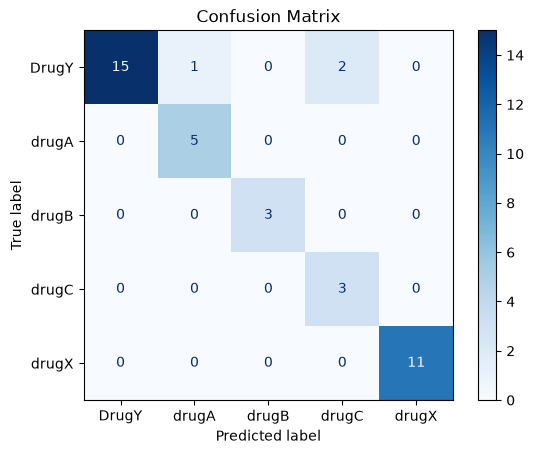

In [75]:
# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_drug.classes_)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

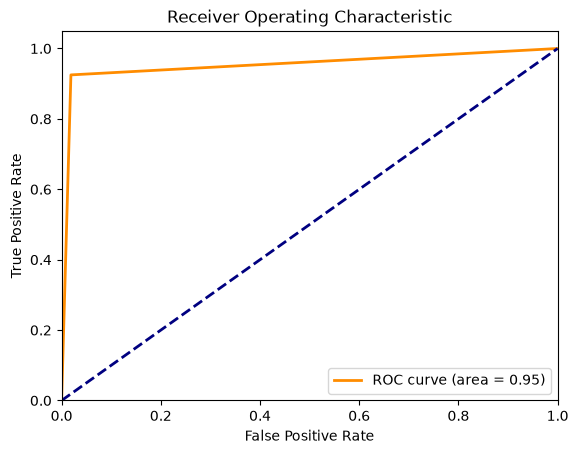

In [76]:
# Binarize the output (required for multiclass ROC)
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Update classes based on your encoded values
y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2, 3, 4])

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


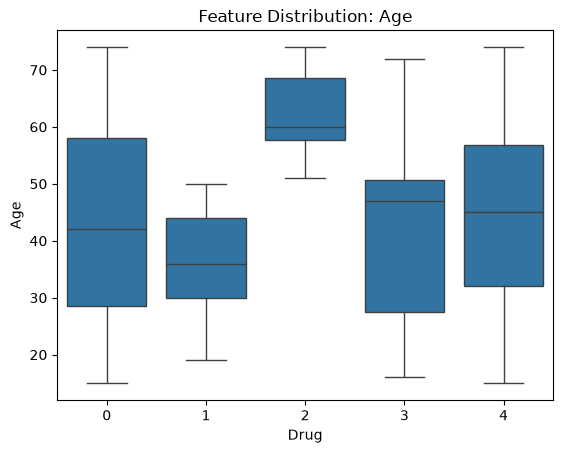

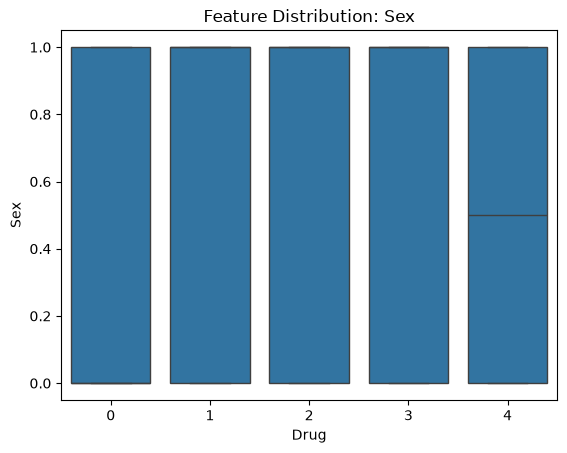

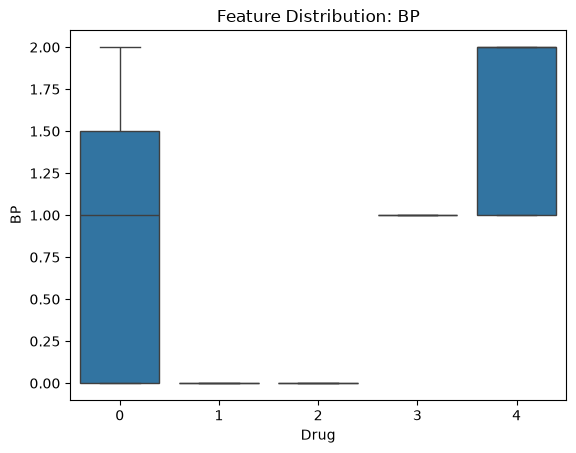

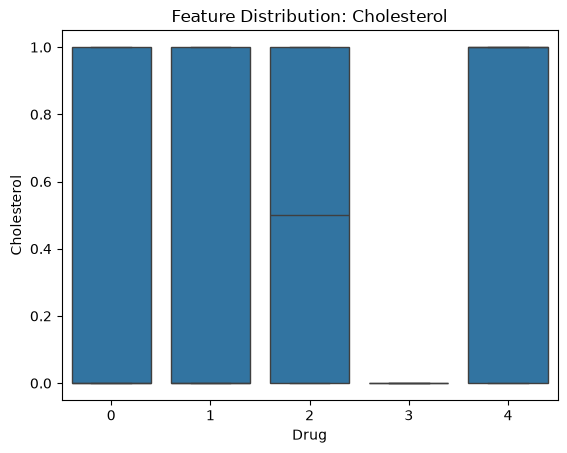

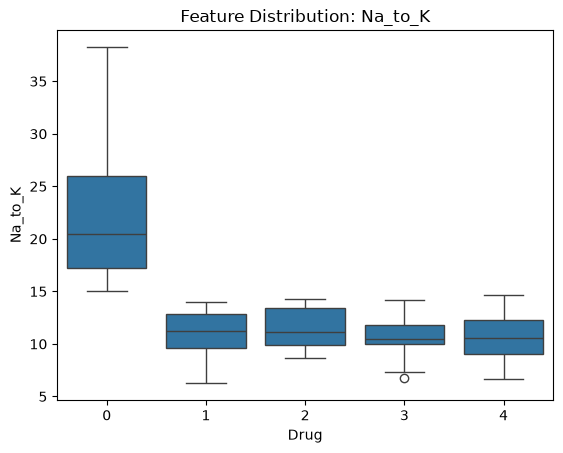

In [77]:
# Visualize the feature distributions for each class
for feature in X.columns:
    sns.boxplot(x=y, y=data[feature], data=data)
    plt.title(f'Feature Distribution: {feature}')
    plt.show()